# Combined FC intra-vs-inter + dataset-size sweep

Stacks the FC intra-vs-inter bar plot (from `fig3_personalization.ipynb`) next to the dataset-size sweep composite (from `fig3_size_robustness.ipynb`) into a single panel image — `ts_young_fc_intra_vs_inter_AND_size_sweep_composite.{pdf,png,svg}`.

Run `fig3_personalization.ipynb` and `fig3_size_robustness.ipynb` first so the input PNGs exist.

In [1]:
from pathlib import Path
import sys

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

plt.rcParams['figure.dpi'] = 140
%matplotlib inline


In [2]:
# Auto-create parent dirs for savefig (added for reproducible runs)
import matplotlib.figure as _mpl_figure
from pathlib import Path as _Path
_orig_savefig = _mpl_figure.Figure.savefig
def _patched_savefig(self, fname, *args, **kwargs):
    if isinstance(fname, (str, _Path)):
        p = _Path(fname)
        if p.parent and not p.parent.exists():
            p.parent.mkdir(parents=True, exist_ok=True)
    return _orig_savefig(self, fname, *args, **kwargs)
_mpl_figure.Figure.savefig = _patched_savefig


In [3]:
DATASET = 'ts_young'
OUT_BASE = project_root / 'paper_new'
COMP_DIR = OUT_BASE / 'images_png' / 'comparison'

LEFT_PNG  = COMP_DIR / f'fc_intra_vs_inter_three_models_{DATASET}.png'
RIGHT_PNG = COMP_DIR / f'{DATASET}_dataset_size_sweep_composite_test_intra_endpoints.png'

for p in (LEFT_PNG, RIGHT_PNG):
    if not p.exists():
        raise FileNotFoundError(
            f'Missing source panel: {p}\n'
            'Run fig3_personalization.ipynb and fig3_size_robustness.ipynb first.'
        )

print(f'Left  panel: {LEFT_PNG}')
print(f'Right panel: {RIGHT_PNG}')


Left  panel: /home/hpc/dsaa/dsaa110h/projects/paper_test2/paper_new/images_png/comparison/fc_intra_vs_inter_three_models_ts_young.png
Right panel: /home/hpc/dsaa/dsaa110h/projects/paper_test2/paper_new/images_png/comparison/ts_young_dataset_size_sweep_composite_test_intra_endpoints.png


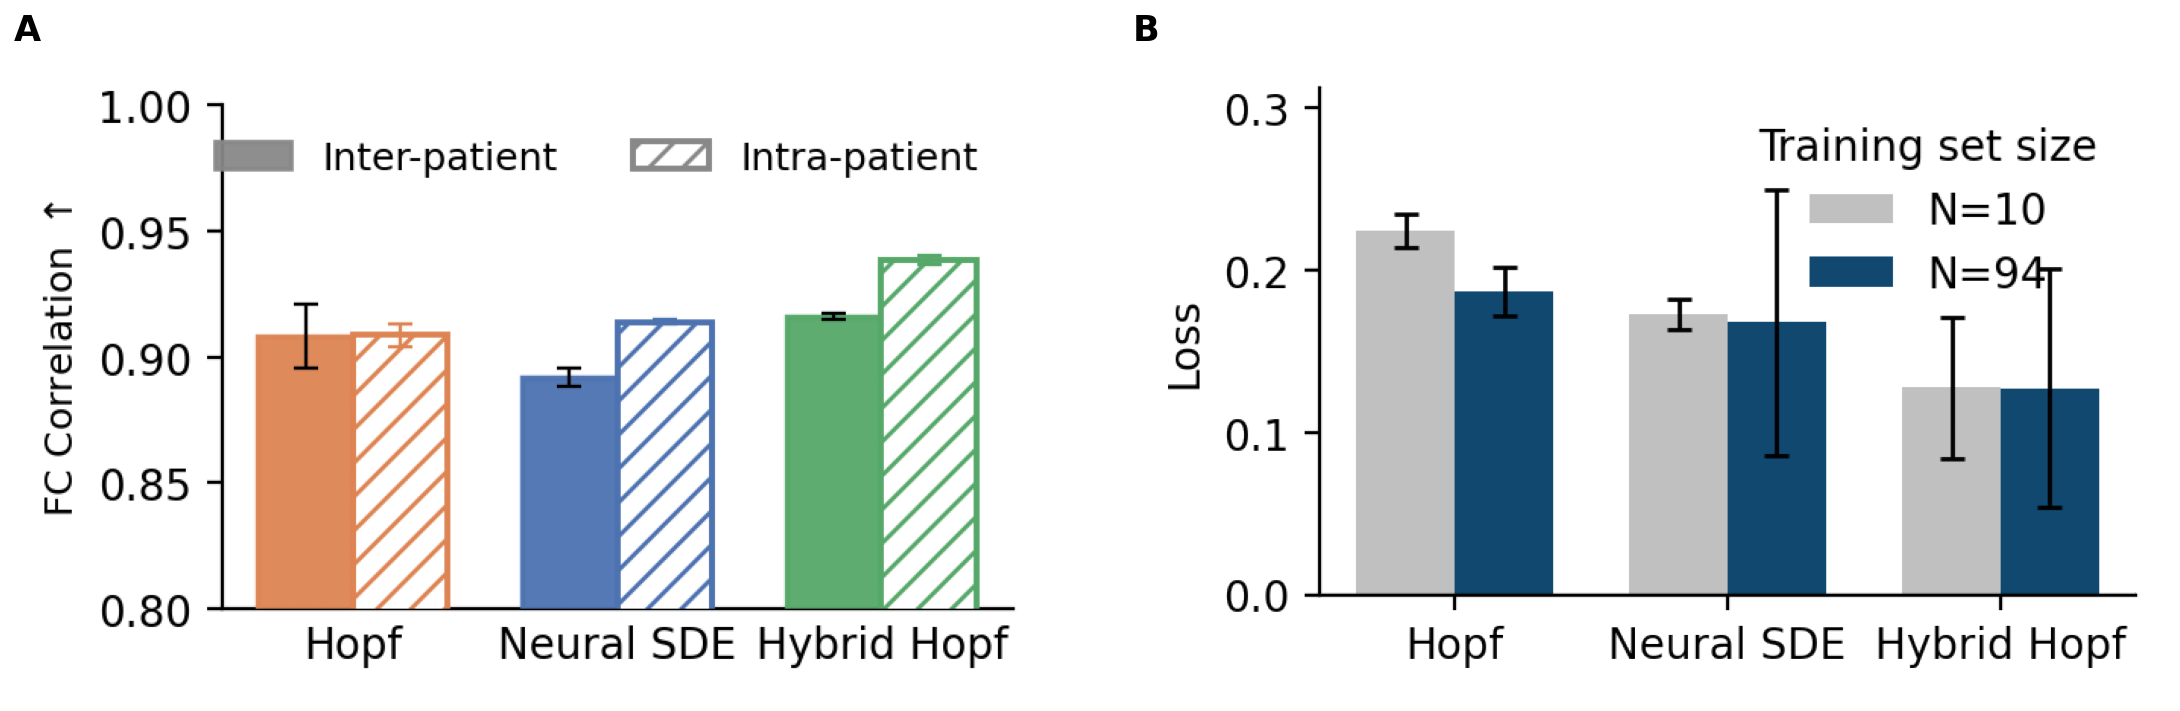

Saved ts_young_fc_intra_vs_inter_AND_size_sweep_composite.pdf/png/svg under /home/hpc/dsaa/dsaa110h/projects/paper_test2/paper_new


In [4]:
left = mpimg.imread(LEFT_PNG)
right = mpimg.imread(RIGHT_PNG)

# Render each panel at the aspect ratio of its source PNG and pick a target
# row height that keeps both readable.
h_left, w_left = left.shape[:2]
h_right, w_right = right.shape[:2]
target_h = 5.0  # inches per panel row
w_left_in = target_h * (w_left / h_left)
w_right_in = target_h * (w_right / h_right)

fig, axes = plt.subplots(
    1, 2,
    figsize=(w_left_in + w_right_in, target_h),
    gridspec_kw={'width_ratios': [w_left_in, w_right_in]},
)
fig.patch.set_alpha(0.0)
for ax, img, label in zip(axes, (left, right), ('A', 'B')):
    ax.imshow(img)
    ax.set_xticks([]); ax.set_yticks([])
    for side in ('top', 'right', 'bottom', 'left'):
        ax.spines[side].set_visible(False)
    ax.text(
        0.0, 1.02, label,
        transform=ax.transAxes,
        fontsize=18, fontweight='bold', va='bottom', ha='left',
    )

fig.tight_layout()

name = f'{DATASET}_fc_intra_vs_inter_AND_size_sweep_composite'
fig.savefig(OUT_BASE / 'images' / 'comparison' / f'{name}.svg', dpi=200, bbox_inches='tight')
fig.savefig(OUT_BASE / 'images_png' / 'comparison' / f'{name}.png', dpi=200, bbox_inches='tight')
fig.savefig(OUT_BASE / 'images_svg' / 'comparison' / f'{name}.svg', bbox_inches='tight')
plt.show()
print(f'Saved {name}.pdf/png/svg under {OUT_BASE}')
